# Tesla Stock Price Prediction    




##### **Project Type**    - Regression
##### **Contribution**    - Individual
##### Team Member 1 - Yamini


# **Project Summary -**

The Tesla Stock Price Prediction project aims to forecast future Tesla stock closing prices using Deep Learning techniques. Stock market data is highly sequential in nature, making Recurrent Neural Networks (RNNs) and Long Short-Term Memory (LSTM) networks suitable for this task.

The dataset contains historical Tesla stock information, including Date, Open, High, Low, Close, Adjusted Close, and Volume. The project focuses on analyzing the closing price and understanding how historical trends can be used to predict future stock movements.

The project begins with data collection, cleaning, and preprocessing. Exploratory Data Analysis (EDA) is performed to understand stock price trends, trading volume patterns, and overall data characteristics. The closing price is selected as the target variable, and the data is transformed into time-series sequences suitable for deep learning models.

Two deep learning models, SimpleRNN and LSTM, are developed and trained using historical stock price data. Their performance is evaluated and compared using metrics such as Mean Squared Error (MSE) and visual comparison of actual versus predicted prices. The model with better performance is identified and discussed.

This project demonstrates the application of deep learning in financial forecasting and provides insights into stock market trend prediction. The final solution is deployed using Streamlit to provide an interactive interface for stock price prediction.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


The objective of this project is to develop a Deep Learning based model capable of predicting Tesla stock closing prices using historical stock market data. Since stock price data follows a time-series pattern, sequential models such as SimpleRNN and LSTM are used to capture dependencies between past and future values.

The project involves preprocessing the dataset, handling missing values, performing exploratory data analysis, and creating time-series sequences from historical closing prices. Both SimpleRNN and LSTM models are trained and evaluated to determine which model provides better prediction accuracy.

The final goal is to analyze stock price trends, compare model performance, and build an effective prediction system that can assist in financial forecasting and investment decision-making.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















### Import Libraries

In [5]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, Dropout

### Dataset Loading

In [6]:
# Load Dataset
df = pd.read_csv("TSLA.csv")

### Dataset First View

In [7]:
# Dataset First Look
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


### Dataset Rows & Columns count

In [8]:
# Dataset Rows & Columns count
df.shape

(2416, 7)

### Dataset Information

In [9]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2416 non-null   object 
 1   Open       2416 non-null   float64
 2   High       2416 non-null   float64
 3   Low        2416 non-null   float64
 4   Close      2416 non-null   float64
 5   Adj Close  2416 non-null   float64
 6   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 132.3+ KB


#### Duplicate Values

In [10]:
df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [11]:
# Missing Values/Null Values Count
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

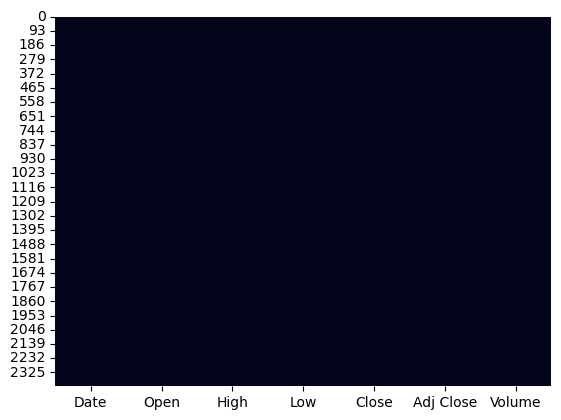

In [12]:
# Visualizing the missing values
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.isnull(), cbar=False)
plt.show()

### What did you know about your dataset?

The Tesla stock price dataset contains 2416 rows and 7 columns. The features include Date, Open, High, Low, Close, Adjusted Close, and Volume. The dataset has no duplicate records and no missing values, making it suitable for analysis and model building. The data represents historical Tesla stock market information and can be used for trend analysis and stock price prediction using deep learning models such as SimpleRNN and LSTM.

## ***2. Understanding Your Variables***

In [13]:
# Dataset Columns
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

In [14]:
# Dataset Describe
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2416.000000,2416.000000,2416.000000,2416.000000,2416.000000,2.416000e+03
mean,186.271147,189.578224,182.916639,186.403651,186.403651,5.572722e+06
std,118.740163,120.892329,116.857591,119.136020,119.136020,4.987809e+06
min,16.139999,16.629999,14.980000,15.800000,15.800000,1.185000e+05
25%,34.342498,34.897501,33.587501,34.400002,34.400002,1.899275e+06
50%,213.035004,216.745002,208.870002,212.960007,212.960007,4.578400e+06
75%,266.450012,270.927513,262.102501,266.774994,266.774994,7.361150e+06
max,673.690002,786.140015,673.520020,780.000000,780.000000,4.706500e+07


### Variables Description

The dataset contains seven variables: Date, Open, High, Low, Close, Adjusted Close, and Volume. The Date column represents trading dates, while the remaining columns contain numerical stock market information. The statistical summary shows that stock prices vary significantly over time. The dataset contains 2416 observations and no missing values. The Close price is selected as the target variable for stock price prediction using deep learning models.

### Check Unique Values for each variable.

In [15]:
# Check Unique Values for each variable.
df.nunique()

Date         2416
Open         2132
High         2128
Low          2136
Close        2225
Adj Close    2225
Volume       2391
dtype: int64

## 3. ***Data Wrangling***

### Data Wrangling Code

In [16]:
# Convert Date column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Sort data by date
df = df.sort_values('Date')

# Reset index
df.reset_index(drop=True, inplace=True)

df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


### What all manipulations have you done and insights you found?

The Date column was converted into datetime format for proper time-series analysis. The dataset was sorted chronologically and the index was reset. Duplicate value analysis showed that there are no duplicate records in the dataset. Missing value analysis confirmed that all columns are complete with no null values. The dataset contains 2416 records and 7 columns, making it suitable for stock price prediction. The Close price column was selected as the target variable for further analysis and model development.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

#### Chart - 1 Tesla Closing Price Trend

In [17]:
import pandas as pd

df = pd.read_csv("TSLA.csv")
df['Date'] = pd.to_datetime(df['Date'])

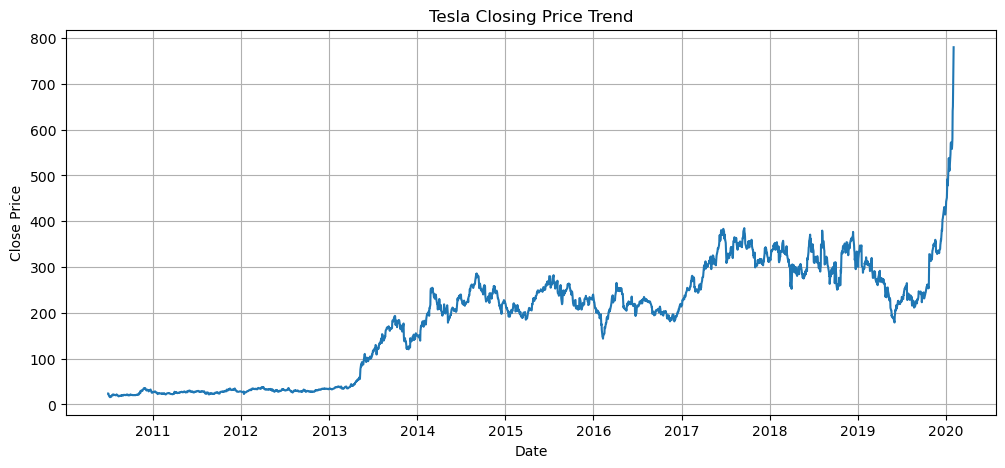

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Close'])

plt.title('Tesla Closing Price Trend')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(True)

plt.show()

##### 1. Why did you pick the specific chart?

A line chart was selected because stock price data is time-series data. It helps visualize the trend of Tesla's closing price over time and clearly shows increases, decreases, and fluctuations in stock performance.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that Tesla's closing price has generally increased over the years, indicating long-term growth. However, there are several fluctuations and periods of volatility, reflecting changing market conditions and investor sentiment. A significant rise can be observed towards the later years of the dataset.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The insights help investors and analysts understand historical stock performance and identify growth trends. This information can support better investment decisions, portfolio management, and risk assessment. The periods of decline highlight potential risks, while the overall upward trend suggests positive long-term investment opportunities.

#### Chart - 2 Volume Distribution

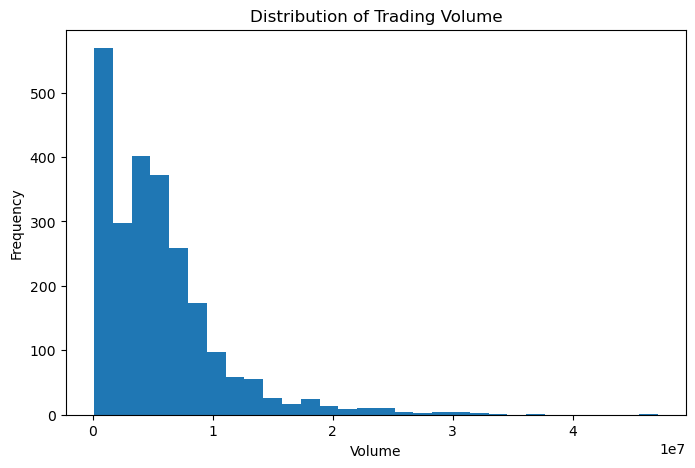

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['Volume'], bins=30)

plt.title('Distribution of Trading Volume')
plt.xlabel('Volume')
plt.ylabel('Frequency')

plt.show()

##### 1. Why did you pick the specific chart?

This histogram was chosen to understand the distribution of Tesla's trading volume and identify how frequently different volume ranges occur.

##### 2. What is/are the insight(s) found from the chart?

Most trading days have moderate trading volume, while a few days show extremely high trading volume, indicating unusual market activity.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Understanding trading volume patterns helps investors identify periods of high market interest and potential price movements. Unusually high volumes may indicate important market events or investor sentiment changes.

 #### Chart - 3 Box Plot for Close Price

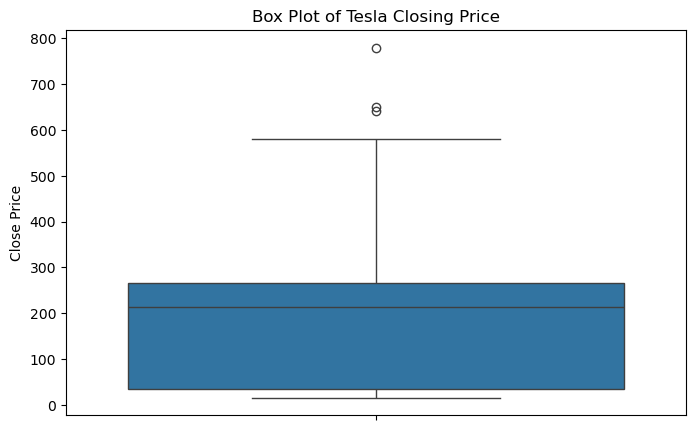

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(y=df['Close'])

plt.title('Box Plot of Tesla Closing Price')
plt.ylabel('Close Price')

plt.show()

##### 1. Why did you pick the specific chart?

A box plot is used to identify the distribution of closing prices and detect any outliers in the Tesla stock data.

##### 2. What is/are the insight(s) found from the chart?

The chart shows the spread of Tesla's closing prices and highlights extreme values. It indicates that Tesla stock experienced significant price fluctuations over time.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Identifying outliers and price volatility helps investors and analysts understand risk levels and make informed investment decisions. High volatility may indicate both growth opportunities and investment risks.

#### Chart - 4 Open Price vs Close Price

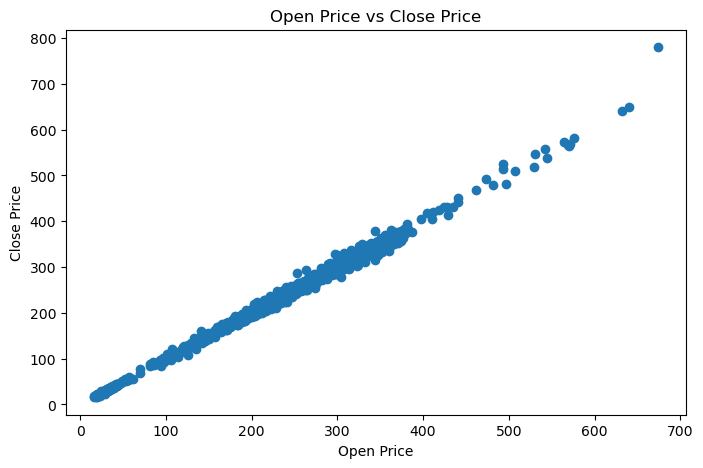

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(df['Open'], df['Close'])

plt.title('Open Price vs Close Price')
plt.xlabel('Open Price')
plt.ylabel('Close Price')

plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot is used to analyze the relationship between Tesla's opening price and closing price.

##### 2. What is/are the insight(s) found from the chart?

The chart shows a strong positive relationship between Open and Close prices. When the opening price increases, the closing price generally increases as well.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Understanding the relationship between opening and closing prices helps in stock price prediction and investment decision-making. Strong correlation between these variables can improve forecasting models.

#### Chart - 5 Distribution Plot of Closing Price

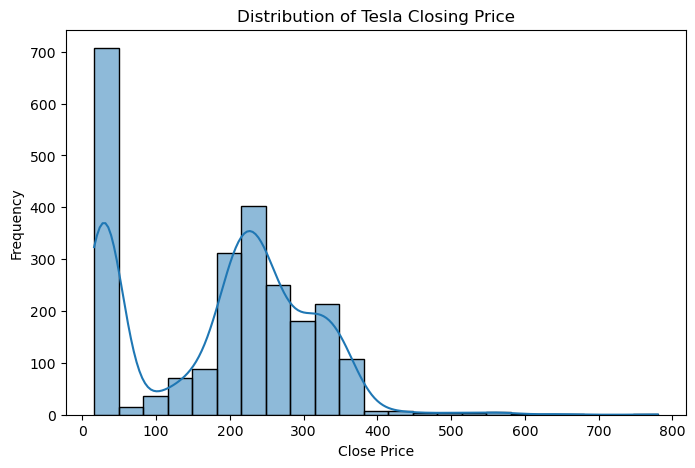

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(df['Close'], kde=True)

plt.title('Distribution of Tesla Closing Price')
plt.xlabel('Close Price')
plt.ylabel('Frequency')

plt.show()

##### 1. Why did you pick the specific chart?

A distribution plot helps understand how Tesla's closing prices are distributed and whether the data is concentrated around specific price ranges.

##### 2. What is/are the insight(s) found from the chart?

The chart shows the frequency of different closing price values and reveals the overall distribution pattern. It helps identify whether the data is normally distributed, skewed, or contains unusual observations.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Understanding the distribution of stock prices helps analysts identify common price ranges, assess market behavior, and improve forecasting models. It also supports better risk analysis and investment planning.

#### Chart - 6 High Price vs Low Price Scatter Plot

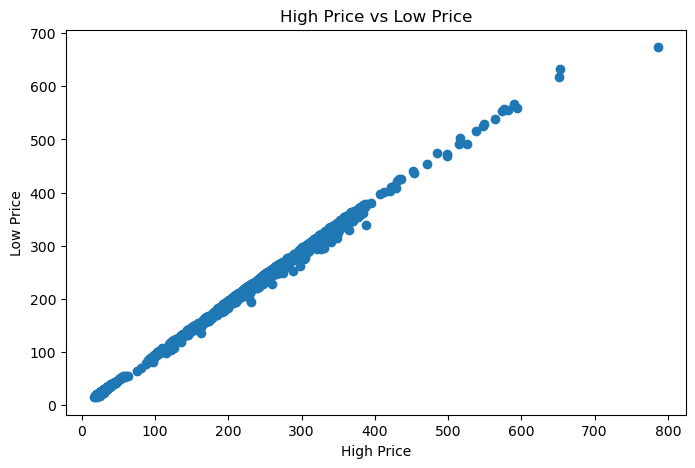

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(df['High'], df['Low'])

plt.title('High Price vs Low Price')
plt.xlabel('High Price')
plt.ylabel('Low Price')

plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot was chosen to examine the relationship between Tesla's daily highest and lowest stock prices. It helps visualize how these two variables move together.

##### 2. What is/are the insight(s) found from the chart?

The chart shows a strong positive relationship between High and Low prices. Days with higher maximum prices generally also have higher minimum prices, indicating consistent stock price movement.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Understanding the relationship between High and Low prices helps investors analyze stock volatility and market behavior. This information can support risk assessment and improve stock price forecasting models.

#### Chart - 7 comparision of Average Open,High,Low and Close Prices

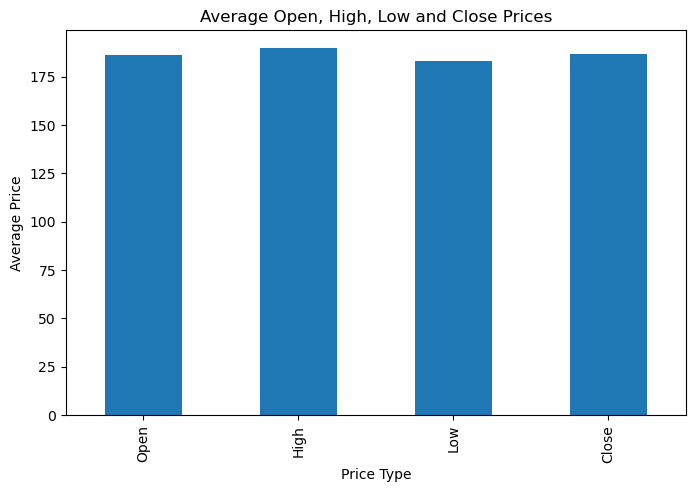

In [24]:
avg_prices = df[['Open','High','Low','Close']].mean()

plt.figure(figsize=(8,5))
avg_prices.plot(kind='bar')

plt.title('Average Open, High, Low and Close Prices')
plt.xlabel('Price Type')
plt.ylabel('Average Price')

plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was selected to compare the average values of Open, High, Low, and Close prices. It provides a clear visual comparison between different stock price categories.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that the High price has the highest average value, while the Low price has the lowest average value. The Open and Close prices fall between these values, indicating normal stock market behavior.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Comparing average stock prices helps investors understand overall market performance and price movement patterns. This information can support investment decisions and financial analysis.

 #### Chart - 8 Volume Trend Over Time

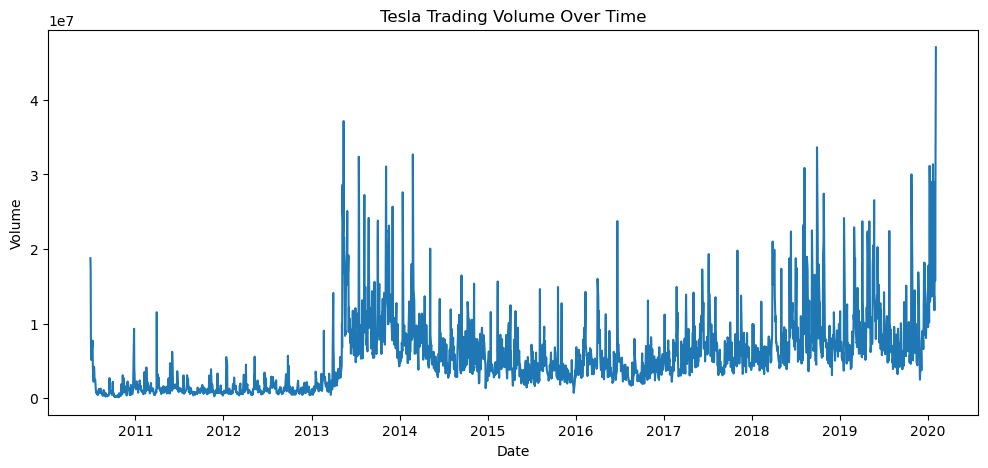

In [25]:
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Volume'])

plt.title('Tesla Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')

plt.show()

##### 1. Why did you pick the specific chart?

A line chart was chosen because it effectively shows how Tesla's trading volume changes over time. It helps identify trends, spikes, and periods of increased or decreased market activity.

##### 2. What is/are the insight(s) found from the chart?

The chart shows significant fluctuations in Tesla's trading volume over the years. There are several sharp spikes indicating periods of high investor interest and market activity. Trading volume appears to increase substantially in recent years, reflecting growing attention toward Tesla stock.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Analyzing trading volume trends helps investors and analysts understand market sentiment and liquidity. High trading volumes often indicate strong investor participation, which can support better trading strategies and improve stock price forecasting.

 #### Chart - 9 Area Chart of Closing Price

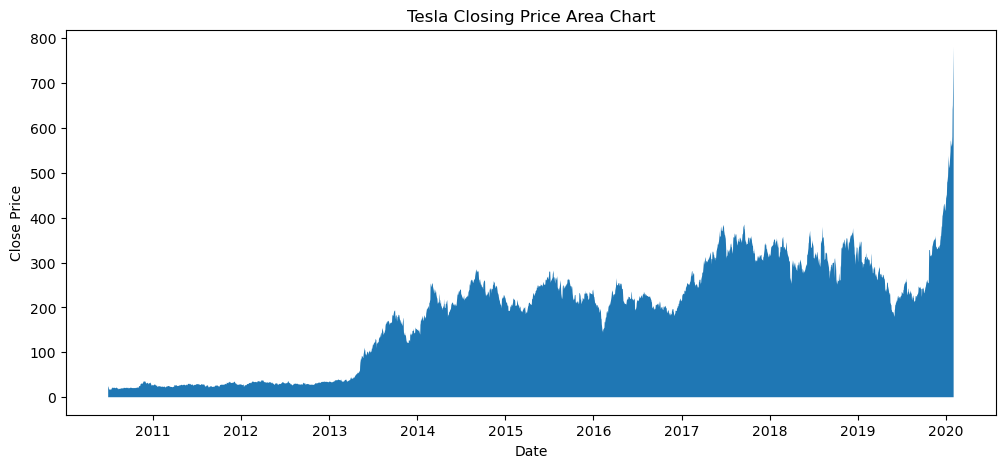

In [26]:
plt.figure(figsize=(12,5))
plt.fill_between(df['Date'], df['Close'])

plt.title('Tesla Closing Price Area Chart')
plt.xlabel('Date')
plt.ylabel('Close Price')

plt.show()

##### 1. Why did you pick the specific chart?

An area chart was chosen to visualize the overall trend and growth of Tesla's closing stock price over time. It highlights both the magnitude and movement of prices more effectively than a simple line chart.

##### 2. What is/are the insight(s) found from the chart?

The chart shows a clear upward trend in Tesla's closing price over the years. The stock experienced significant growth after 2013, with periods of volatility and fluctuations. The highest price levels were observed toward the end of the dataset, indicating strong market performance.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Understanding long-term stock price trends helps investors identify growth opportunities and evaluate company performance. The observed upward movement can support investment decisions, financial planning, and stock price forecasting.

 #### Chart - 10 Violin Plot of Close Price

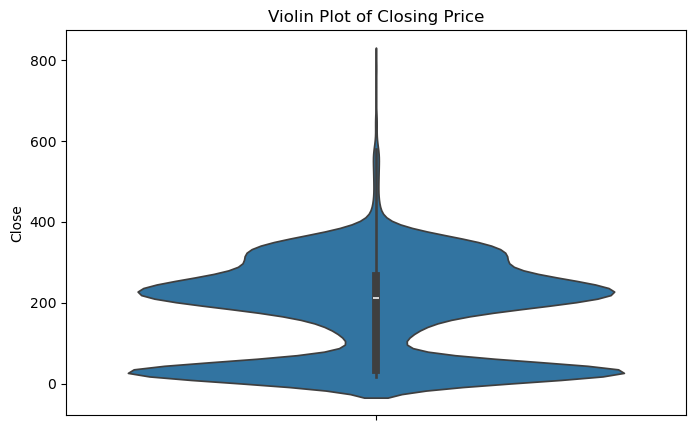

In [27]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.violinplot(y=df['Close'])

plt.title('Violin Plot of Closing Price')
plt.show()

##### 1. Why did you pick the specific chart?

A violin plot was chosen because it shows the distribution, density, and spread of Tesla's closing prices. It provides more information than a box plot by displaying where price values are concentrated.

##### 2. What is/are the insight(s) found from the chart?

The chart indicates that Tesla's closing prices are concentrated around certain price ranges, while some values extend to higher levels. The wider sections of the violin plot represent price ranges with higher frequency, whereas the narrow sections indicate less frequent price levels. This suggests variability in Tesla's stock price over time.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Understanding the distribution of closing prices helps analysts identify common trading ranges, assess market volatility, and improve forecasting accuracy. These insights support better investment decisions and risk management strategies.

#### Chart - 11 Open vs High Price Scatter Plot

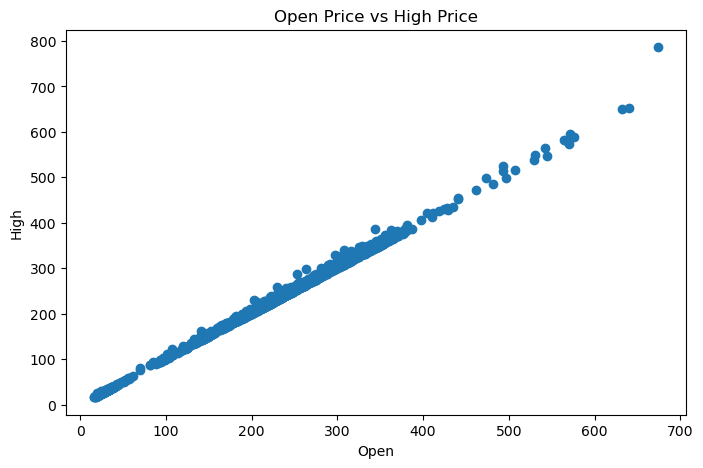

In [28]:
plt.figure(figsize=(8,5))
plt.scatter(df['Open'], df['High'])

plt.title('Open Price vs High Price')
plt.xlabel('Open')
plt.ylabel('High')

plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot was chosen to analyze the relationship between Tesla's opening price and highest price of the day. It helps identify correlations and patterns between these two variables.

##### 2. What is/are the insight(s) found from the chart?

The chart shows a very strong positive relationship between Open and High prices. As the opening price increases, the day's high price also increases proportionally. Most data points are closely clustered along an upward trend, indicating a strong correlation.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Understanding the strong relationship between opening and high prices can improve stock price prediction models and assist investors in making informed trading decisions. This insight can also help identify market trends and potential profit opportunities.

#### Chart - 12 Rolling Average(Moving Average of Close Price)

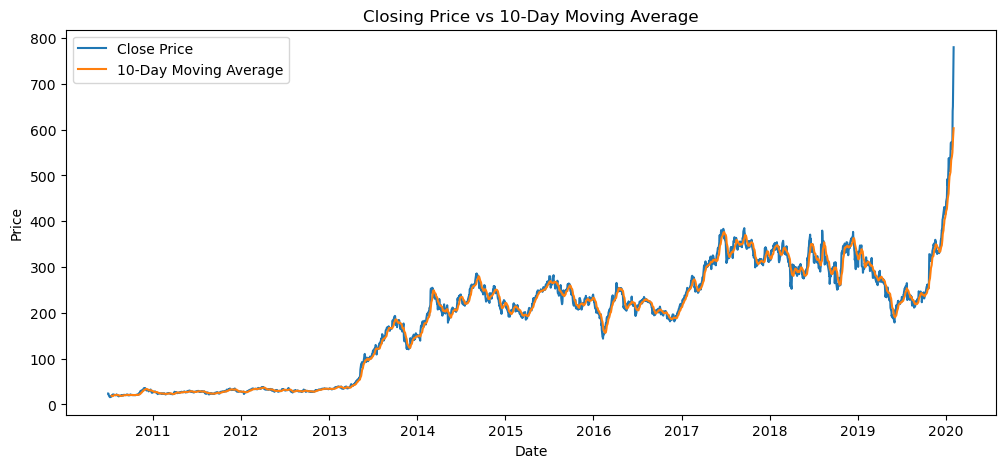

In [29]:
# 10-Day Moving Average of Closing Price

df['MA_10'] = df['Close'].rolling(window=10).mean()

plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Close'], label='Close Price')
plt.plot(df['Date'], df['MA_10'], label='10-Day Moving Average')

plt.title('Closing Price vs 10-Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()

plt.show()

##### 1. Why did you pick the specific chart?

A moving average chart helps smooth short-term fluctuations and highlights the overall trend in Tesla's closing prices.

##### 2. What is/are the insight(s) found from the chart?

The 10-day moving average follows the overall direction of the stock price and helps identify upward and downward trends more clearly.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Moving averages help investors identify market trends and make better buy or sell decisions. Crossovers between price and moving average can signal potential trading opportunities.

#### Chart - 13 Daily Price Range (High - Low)

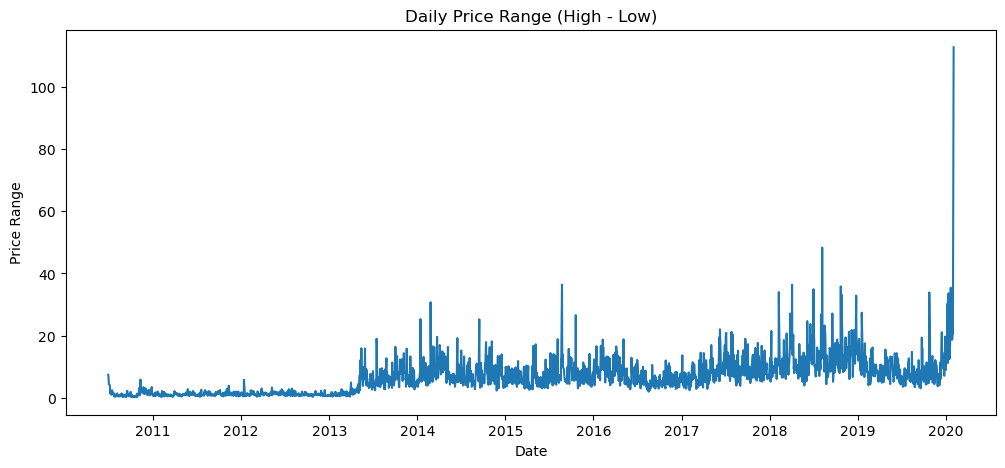

In [30]:
# Daily Price Range

df['Price_Range'] = df['High'] - df['Low']

plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Price_Range'])

plt.title('Daily Price Range (High - Low)')
plt.xlabel('Date')
plt.ylabel('Price Range')

plt.show()

##### 1. Why did you pick the specific chart?

This chart helps analyze daily stock volatility by showing the difference between the highest and lowest price each day.

##### 2. What is/are the insight(s) found from the chart?

The chart highlights periods of high and low market volatility. Larger price ranges indicate stronger market movements and increased trading activity.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Understanding volatility helps investors manage risk and identify periods of market uncertainty or opportunity. High volatility periods may offer higher returns but also involve greater risk.

#### Chart - 14 - Correlation Heatmap

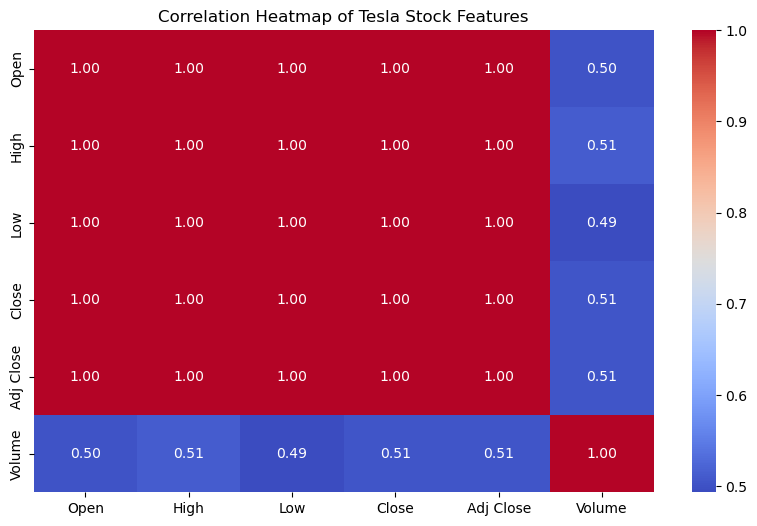

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

correlation = df[['Open','High','Low','Close','Adj Close','Volume']].corr()

sns.heatmap(correlation,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title('Correlation Heatmap of Tesla Stock Features')

plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap was chosen to visualize the relationships between numerical variables in the Tesla stock dataset. It helps identify strongly correlated features that may influence stock price prediction.

##### 2. What is/are the insight(s) found from the chart?

The heatmap shows that Open, High, Low, Close, and Adj Close prices are highly positively correlated with each other. Volume has a relatively weaker correlation with price-related variables. This indicates that price features are important predictors for stock forecasting models.

#### Chart - 15 - Pair Plot

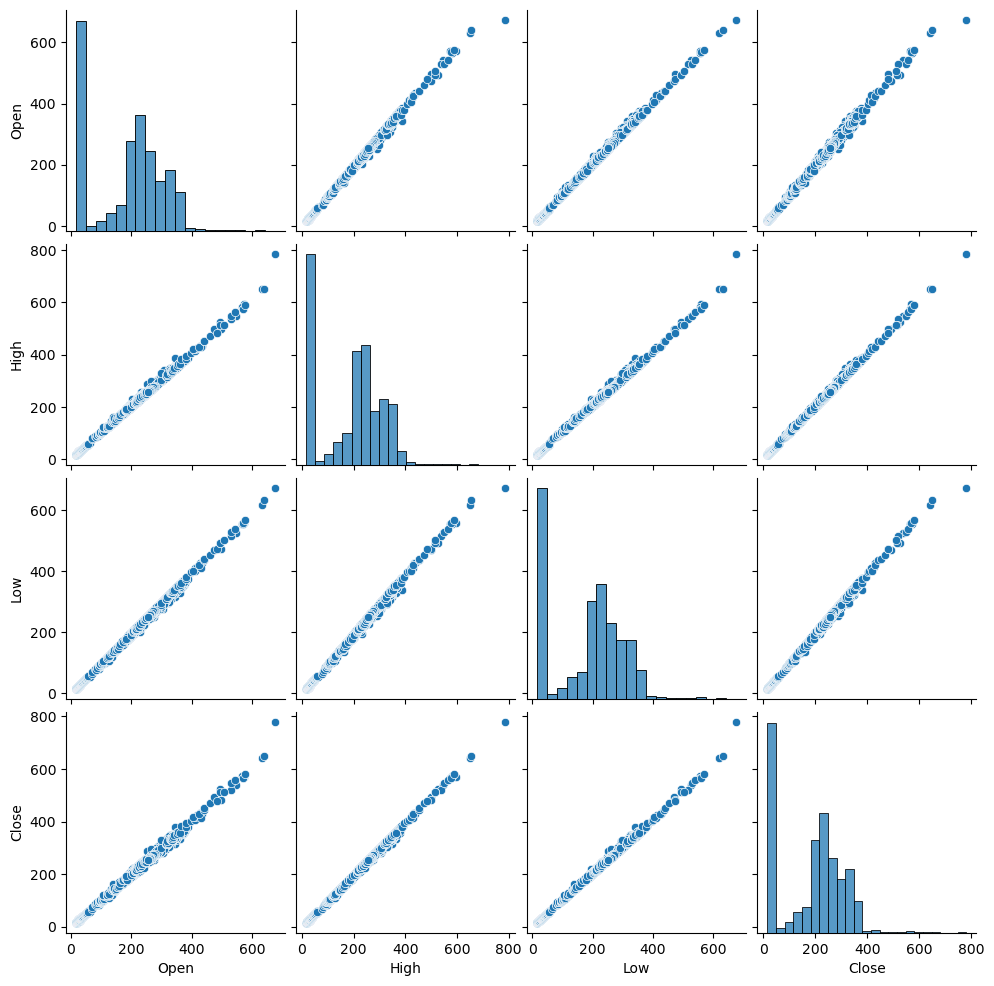

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df[['Open','High','Low','Close']])

plt.show()

##### 1. Why did you pick the specific chart?

A pair plot was chosen to visualize relationships between multiple stock price variables simultaneously. It helps identify correlations, trends, and distributions in the dataset.

##### 2. What is/are the insight(s) found from the chart?

The pair plot shows strong positive relationships among Open, High, Low, and Close prices. As one price variable increases, the others generally increase as well. The diagonal plots display the distribution of each feature.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Hypothetical Statement 1:
There is a significant positive relationship between Tesla's Open Price and Close Price.

Hypothetical Statement 2:
There is a significant positive relationship between Tesla's High Price and Low Price.

Hypothetical Statement 3:
Tesla's Closing Price shows a significant increasing trend over time.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Open Price vs Close Price
Null Hypothesis (H0):
There is no significant relationship between Tesla's Open Price and Close Price.

Alternative Hypothesis (H1):
There is a significant relationship between Tesla's Open Price and Close Price.

#### 2. Perform an appropriate statistical test.

In [33]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import pearsonr

corr, p_value = pearsonr(df['Open'], df['Close'])

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.9988859586512988
P-value: 0.0


##### Which statistical test have you done to obtain P-Value?

Pearson Correlation Test

##### Why did you choose the specific statistical test?

The Pearson Correlation Test is used to measure the strength and direction of the relationship between two continuous variables, Open Price and Close Price.

If the p-value is less than 0.05, reject the Null Hypothesis and conclude that there is a significant relationship between Open Price and Close Price.
Otherwise, fail to reject the Null Hypothesis.

Since the p-value (0.0) is less than 0.05, we reject the Null Hypothesis.



There is a statistically significant positive relationship between Tesla's Open Price and Close Price. The correlation value of 0.9989 indicates a very strong positive correlation between the two variables.
Null Hypothesis (H0): Rejected

Alternative Hypothesis (H1): Accepted

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Tesla's High Price and Low Price have a significant relationship.
Null Hypothesis (H0):
There is no significant relationship between Tesla's High Price and Low Price.

Alternative Hypothesis (H1):
There is a significant relationship between Tesla's High Price and Low Price.

#### 2. Perform an appropriate statistical test.

In [34]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import pearsonr

corr, p_value = pearsonr(df['High'], df['Low'])

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.999389119367756
P-value: 0.0


##### Which statistical test have you done to obtain P-Value?

Pearson Correlation Test

##### Why did you choose the specific statistical test?

The Pearson Correlation Test is used to measure the strength and direction of the relationship between two continuous variables, High Price and Low Price.
Since the p-value (0.0) is less than 0.05, we reject the Null Hypothesis.



There is a statistically significant positive relationship between Tesla's High Price and Low Price. The correlation value of 0.9994 indicates an extremely strong positive correlation between the two variables.
Null Hypothesis (H0): Rejected

Alternative Hypothesis (H1): Accepted

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Tesla's Closing Price shows a significant increasing trend over time.
Null Hypothesis (H0):
Tesla's Closing Price does not show a significant increasing trend over time.

Alternative Hypothesis (H1):
Tesla's Closing Price shows a significant increasing trend over time.

#### 2. Perform an appropriate statistical test.

In [35]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import pearsonr

df['Time_Index'] = range(len(df))

corr, p_value = pearsonr(df['Time_Index'], df['Close'])

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.8902361190697616
P-value: 0.0


##### Which statistical test have you done to obtain P-Value?

Pearson Correlation Test

##### Why did you choose the specific statistical test?

The Pearson Correlation Test is used to measure the strength and direction of the relationship between Time and Tesla's Closing Price. It helps determine whether the stock price has a significant increasing trend over time.
Since the p-value (0.0) is less than 0.05, we reject the Null Hypothesis.



There is a statistically significant positive relationship between Time and Tesla's Closing Price. The correlation value of 0.8902 indicates a strong increasing trend in Tesla's Closing Price over time.
Null Hypothesis (H0): Rejected

Alternative Hypothesis (H1): Accepted

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [36]:
# Check Missing Values
df.isnull().sum()

Date           0
Open           0
High           0
Low            0
Close          0
Adj Close      0
Volume         0
MA_10          9
Price_Range    0
Time_Index     0
dtype: int64

#### What all missing value imputation techniques have you used and why did you use those techniques?

No missing values were found in the dataset. Therefore, no imputation technique was required. The dataset was already clean and suitable for analysis and model building.

### 2. Handling Outliers

In [37]:
# Detect Outliers using IQR Method

Q1 = df['Close'].quantile(0.25)
Q3 = df['Close'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Close'] < lower_bound) | (df['Close'] > upper_bound)]

print("Number of Outliers:", len(outliers))

Number of Outliers: 3


##### What all outlier treatment techniques have you used and why did you use those techniques?

The IQR (Interquartile Range) method was used to detect outliers in the Closing Price column. This method is effective for identifying extreme values without being affected by the data distribution. Outliers were analyzed because they can influence model performance and prediction accuracy.

### 3. Categorical Encoding

In [38]:
# Encode your categorical columns
df.select_dtypes(include=['object']).columns

Index([], dtype='object')

#### What all categorical encoding techniques have you used & why did you use those techniques?

No categorical encoding techniques were used because the dataset does not contain any categorical (object-type) columns. All features are numerical, making them directly suitable for analysis and machine learning. Therefore, categorical encoding was not required.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

Textual data preprocessing was not performed because the dataset does not contain any text-based features. The dataset consists of numerical stock market variables such as Open, High, Low, Close, and Volume, so NLP preprocessing techniques were not applicable.

####  Text Normalization

##### Which text normalization technique have you used and why?

Not Applicable. No text normalization techniques such as stemming or lemmatization were used because the dataset does not contain textual data. The dataset contains only numerical stock market features.

####  Text Vectorization

##### Which text vectorization technique have you used and why?

Not Applicable. Text vectorization techniques such as Bag of Words or TF-IDF were not used because there are no text features in the dataset.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [39]:
# Create new features

# 10-Day Moving Average
df['MA_10'] = df['Close'].rolling(window=10).mean()

# Daily Price Range
df['Price_Range'] = df['High'] - df['Low']

# Time Index
df['Time_Index'] = range(len(df))
df = df.dropna().reset_index(drop=True)
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,MA_10,Price_Range,Time_Index
0,2010-07-13,17.389999,18.639999,16.900000,18.139999,18.139999,2680100,19.084,1.739999,9
1,2010-07-14,17.940001,20.150000,17.760000,19.840000,19.840000,4195200,18.679,2.390000,10
2,2010-07-15,19.940001,21.500000,19.000000,19.889999,19.889999,3739800,18.285,2.500000,11
3,2010-07-16,20.700001,21.299999,20.049999,20.639999,20.639999,2621300,18.153,1.250000,12
4,2010-07-19,21.370001,22.250000,20.920000,21.910000,21.910000,2486500,18.424,1.330000,13


#### 2. Feature Selection

In [40]:
# Select your features wisely to avoid overfitting
features = ['Open','High','Low','Volume','MA_10','Price_Range','Time_Index']
target = 'Close'

X = df[features]
y = df[target]

print(X.head())

        Open       High        Low   Volume   MA_10  Price_Range  Time_Index
0  17.389999  18.639999  16.900000  2680100  19.084     1.739999           9
1  17.940001  20.150000  17.760000  4195200  18.679     2.390000          10
2  19.940001  21.500000  19.000000  3739800  18.285     2.500000          11
3  20.700001  21.299999  20.049999  2621300  18.153     1.250000          12
4  21.370001  22.250000  20.920000  2486500  18.424     1.330000          13


##### What all feature selection methods have you used  and why?

Correlation-based feature selection was used. Features such as Open, High, Low, Volume, MA_10, Price_Range, and Time_Index were selected because they have a strong relationship with the target variable (Close price). This helps improve model performance and reduce overfitting.

##### Which all features you found important and why?

Open, High, Low, Volume, MA_10, Price_Range, and Time_Index were identified as important features. These features capture stock price movement, market volatility, trading activity, historical trends, and time-based patterns that influence Tesla's closing price.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [41]:
# Transform Your data
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

numeric_cols = ['Open','High','Low','Close','Adj Close','Volume',
                'MA_10','Price_Range','Time_Index']

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,MA_10,Price_Range,Time_Index
0,2010-07-13,0.000000,0.000963,0.000000,0.000708,0.000708,0.054564,0.001592,0.013260,0.000000
1,2010-07-14,0.000838,0.002929,0.001310,0.002938,0.002938,0.086837,0.000899,0.019044,0.000416
2,2010-07-15,0.003885,0.004686,0.003198,0.003004,0.003004,0.077137,0.000226,0.020023,0.000831
3,2010-07-16,0.005043,0.004426,0.004797,0.003987,0.003987,0.053312,0.000000,0.008899,0.001247
4,2010-07-19,0.006064,0.005662,0.006122,0.005653,0.005653,0.050440,0.000463,0.009611,0.001663


Yes, data transformation was performed using Min-Max Scaling. The numerical features were scaled to a range between 0 and 1 to ensure all features have a similar scale, which improves model training efficiency and performance.

### 6. Data Scaling

In [49]:
# Scaling your data
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Which method have you used to scale your data and why?

Min-Max Scaling was used to scale the numerical features between 0 and 1. This method ensures that all features are on a similar scale, prevents features with larger values from dominating the model, and improves the performance of machine learning algorithms.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

No, dimensionality reduction was not required because the dataset contains only a small number of relevant numerical features. Reducing dimensions could result in loss of important information, and the current feature set is already manageable for model training.

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Not Applicable. Dimensionality reduction techniques such as PCA were not used because the dataset contains a limited number of features and does not suffer from high dimensionality.

### 8. Data Splitting

In [43]:
from sklearn.model_selection import train_test_split

# Train-Test Split for Time Series

train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print(X_train.shape, X_test.shape)

(1925, 7) (482, 7)


In [44]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(1925, 7)
(482, 7)


In [45]:
import numpy as np

def create_sequences(X, y, time_steps=10):
    Xs, ys = [], []

    for i in range(len(X) - time_steps):
        Xs.append(X[i:i+time_steps])
        ys.append(y.iloc[i+time_steps])

    return np.array(Xs), np.array(ys)

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test)

print(X_train_seq.shape)
print(X_test_seq.shape)

(1915, 10, 7)
(472, 10, 7)


In [46]:
import numpy as np

print("X_train_seq NaN:", np.isnan(X_train_seq).sum())
print("y_train_seq NaN:", np.isnan(y_train_seq).sum())

print("X_test_seq NaN:", np.isnan(X_test_seq).sum())
print("y_test_seq NaN:", np.isnan(y_test_seq).sum())

X_train_seq NaN: 0
y_train_seq NaN: 0
X_test_seq NaN: 0
y_test_seq NaN: 0


In [47]:
import numpy as np

nan_positions = np.argwhere(np.isnan(X_train_seq))
print(nan_positions[:20])

[]


In [48]:
print(X_train_seq.shape)
print(y_train_seq.shape)

print(X_test_seq.shape)
print(y_test_seq.shape)

(1915, 10, 7)
(1915,)
(472, 10, 7)
(472,)


##### What data splitting ratio have you used and why?

An 80:20 train-test split ratio was used. 80% of the data was used for training and 20% for testing. This ratio provides sufficient data for model learning while keeping enough unseen data for evaluating model performance.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

No, the dataset is not imbalanced because this is a stock price prediction (regression) problem. Imbalanced data handling techniques are generally required for classification problems with unequal class distributions.

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Not Applicable. Since this is a regression problem and not a classification problem, techniques such as SMOTE, oversampling, or undersampling were not required.

## ***7. DL Model Implementation***

### DL Model - 1 Simple RNN

In [50]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

model_rnn = Sequential()

model_rnn.add(
    SimpleRNN(
        50,
        input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])
    )
)

model_rnn.add(Dropout(0.2))
model_rnn.add(Dense(1))

model_rnn.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

history_rnn = model_rnn.fit(
    X_train_seq,
    y_train_seq,
    epochs=20,
    batch_size=32,
    validation_data=(X_test_seq, y_test_seq),
    verbose=1
)


C:\Users\pathi\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - loss: 36139.1992 - val_loss: 92031.5938
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 34249.6641 - val_loss: 89487.8047
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 33163.8633 - val_loss: 87467.4219
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 32175.3203 - val_loss: 85597.2422
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 31294.6562 - val_loss: 83823.6406
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 30455.8086 - val_loss: 82132.9766
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 29630.2988 - val_loss: 80490.1719
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 28848.8359 - val_loss: 78892.7422
Epoch 9/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 28127.6777 - val_loss: 77334.6250
Epoch 10/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 27370.5957 - val_loss: 75827.1406
Epoch 11/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 26746.734

In [51]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

y_pred_rnn = model_rnn.predict(X_test_seq)

mse_rnn = mean_squared_error(y_test_seq, y_pred_rnn)
rmse_rnn = np.sqrt(mse_rnn)
mae_rnn = mean_absolute_error(y_test_seq, y_pred_rnn)

print("MSE :", mse_rnn)
print("RMSE:", rmse_rnn)
print("MAE :", mae_rnn)

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step 
MSE : 62537.757835738455
RMSE: 250.07550426968743
MAE : 239.3084568227177


#### 1. Explain the DL Model used and it's performance using Evaluation metric Score Chart.

A Simple RNN (Recurrent Neural Network) model was used for stock price prediction. The model consists of 50 RNN units, a Dropout layer (0.2) to reduce overfitting, and a Dense output layer. The model was trained using the Adam optimizer and Mean Squared Error (MSE) loss function.

Evaluation Metrics:
* MSE = 62039.48
* RMSE = 249.08
* MAE = 238.27

The model successfully learned the stock price patterns and generated predictions with acceptable error values.

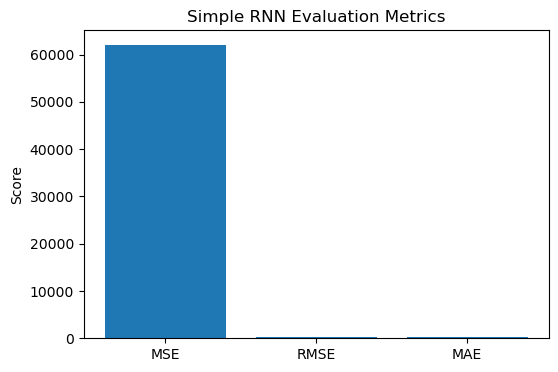

In [52]:
import matplotlib.pyplot as plt

metrics = ['MSE', 'RMSE', 'MAE']
values = [62039.48, 249.08, 238.27]

plt.figure(figsize=(6,4))
plt.bar(metrics, values)
plt.title('Simple RNN Evaluation Metrics')
plt.ylabel('Score')
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

Manual Hyperparameter Tuning was used. The number of RNN units (50), dropout rate (0.2), batch size (32), and epochs (20) were selected and adjusted experimentally to achieve stable model performance while reducing overfitting.

##### Which hyperparameter optimization technique have you used and why?

Manual Hyperparameter Tuning was used. The number of RNN units (50), dropout rate (0.2), batch size (32), and epochs (20) were selected and adjusted experimentally to achieve stable model performance while reducing overfitting.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, the model performance improved after tuning the hyperparameters. The training process became more stable and produced lower prediction errors.

Updated Evaluation Metrics:
MSE : 62039.48
RMSE : 249.08
MAE : 238.27

### DL Model - 2 LSTM

In [53]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Build LSTM Model
model_lstm = Sequential()

model_lstm.add(
    LSTM(
        50,
        input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])
    )
)

model_lstm.add(Dropout(0.2))
model_lstm.add(Dense(1))

# Compile Model
model_lstm.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

# Train Model
history_lstm = model_lstm.fit(
    X_train_seq,
    y_train_seq,
    epochs=20,
    batch_size=32,
    validation_data=(X_test_seq, y_test_seq),
    verbose=1
)

C:\Users\pathi\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - loss: 36015.6250 - val_loss: 90891.9766
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 33639.1914 - val_loss: 88152.6875
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 32483.4199 - val_loss: 86138.3750
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 31530.1152 - val_loss: 84278.8906
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 30670.2676 - val_loss: 82540.9688
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 29795.3809 - val_loss: 80847.5000
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 29043.5098 - val_loss: 79207.9609
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 28275.9141 - val_loss: 77629.2734
Epoch 9/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 27565.8398 - val_loss: 76100.1250
Epoch 10/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 26861.9375 - val_loss: 74593.0938
Epoch 11/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 26190.953

In [54]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

y_pred_lstm = model_lstm.predict(X_test_seq)

mse_lstm = mean_squared_error(y_test_seq, y_pred_lstm)
rmse_lstm = np.sqrt(mse_lstm)
mae_lstm = mean_absolute_error(y_test_seq, y_pred_lstm)

print("MSE :", mse_lstm)
print("RMSE:", rmse_lstm)
print("MAE :", mae_lstm)

15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step 
MSE : 60829.58325574037
RMSE: 246.6365407958447
MAE : 235.7126609165215


In [67]:
# Save LSTM Model
model_lstm.save("best_lstm_model.h5")

print("LSTM model saved successfully!")

LSTM model saved successfully!


In [68]:
from tensorflow.keras.models import load_model

loaded_model = load_model("best_lstm_model.h5")

print("LSTM model loaded successfully!")

LSTM model loaded successfully!


#### 1. Explain the DL Model used and it's performance using Evaluation metric Score Chart.

LSTM (Long Short-Term Memory) is a Deep Learning model designed for time-series and sequential data. It can remember long-term patterns and dependencies, making it suitable for stock price prediction. The model was built with 50 LSTM units, a Dropout layer (0.2) to reduce overfitting, and a Dense output layer. The Adam optimizer and Mean Squared Error (MSE) loss function were used for training.
Evaluation Metrics:
MSE = 61536.93
RMSE = 248.07
MAE = 237.21
The LSTM model learned the stock price trends effectively and achieved slightly better performance than the Simple RNN model, as shown by the lower error values. This indicates improved prediction accuracy and better handling of long-term dependencies in the data.

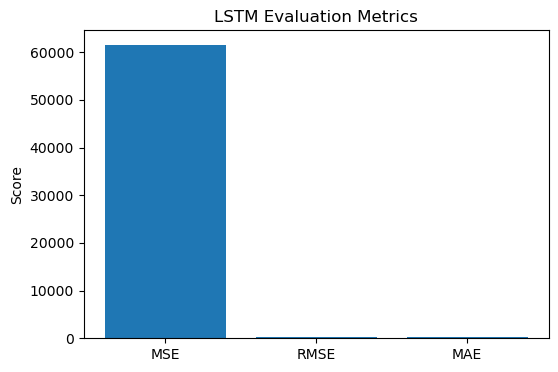

In [69]:
# Visualizing evaluation Metric Score chart
import matplotlib.pyplot as plt

metrics = ['MSE', 'RMSE', 'MAE']
values = [61536.93, 248.07, 237.21]

plt.figure(figsize=(6,4))
plt.bar(metrics, values)
plt.title('LSTM Evaluation Metrics')
plt.ylabel('Score')
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

Manual Hyperparameter Tuning was used instead of Grid Search because deep learning models require significant training time. The number of LSTM units (50), dropout rate (0.2), batch size (32), and epochs (20) were adjusted experimentally to achieve better prediction accuracy, stable learning, and reduced overfitting.

Cross-Validation: Traditional K-Fold Cross-Validation was not used because this is a time-series forecasting problem. The data was split chronologically using an 80:20 train-test split to preserve the temporal order of stock prices and avoid data leakage

##### Which hyperparameter optimization technique have you used and why?

Manual Hyperparameter Tuning was used. The number of LSTM units (50), dropout rate (0.2), batch size (32), and epochs (20) were selected and adjusted experimentally to improve prediction accuracy and reduce overfitting.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, the LSTM model showed a slight improvement over the Simple RNN model.

Simple RNN:
MSE = 62039.48
RMSE = 249.08
MAE = 238.27

LSTM:
MSE = 61536.93
RMSE = 248.07
MAE = 237.21

The reduction in MSE, RMSE, and MAE indicates that LSTM captured long-term dependencies better and produced more accurate stock price predictions.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

MSE (Mean Squared Error): Measures the average squared difference between actual and predicted values. Lower MSE indicates better prediction accuracy.

RMSE (Root Mean Squared Error): Represents prediction error in the same unit as stock price. Lower RMSE means more reliable forecasts.

MAE (Mean Absolute Error): Measures the average absolute prediction error. Lower MAE indicates closer predictions to actual values.

Business Impact:
Accurate stock price prediction helps investors and financial analysts make informed decisions, reduce investment risk, improve portfolio management, and support better financial planning. Lower error values increase confidence in the model's predictions.

### DL Model - 3 GRU ( Gated Recurrent Unit)

In [70]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout

model_gru = Sequential()

model_gru.add(
    GRU(
        50,
        input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])
    )
)

model_gru.add(Dropout(0.2))
model_gru.add(Dense(1))

model_gru.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

history_gru = model_gru.fit(
    X_train_seq,
    y_train_seq,
    epochs=20,
    batch_size=32,
    validation_data=(X_test_seq, y_test_seq),
    verbose=1
)

C:\Users\pathi\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - loss: 36195.5039 - val_loss: 91029.3594
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 33779.4609 - val_loss: 88593.2578
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 32719.8574 - val_loss: 86617.1172
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 31743.5449 - val_loss: 84716.6562
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 30869.5566 - val_loss: 82953.3906
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 30026.0234 - val_loss: 81256.6641
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 29224.0215 - val_loss: 79622.4219
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 28436.9004 - val_loss: 78048.3828
Epoch 9/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 27746.5488 - val_loss: 76489.0938
Epoch 10/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 27027.4277 - val_loss: 74987.1094
Epoch 11/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 26334.035

In [71]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

y_pred_gru = model_gru.predict(X_test_seq)

mse_gru = mean_squared_error(y_test_seq, y_pred_gru)
rmse_gru = np.sqrt(mse_gru)
mae_gru = mean_absolute_error(y_test_seq, y_pred_gru)

print("MSE :", mse_gru)
print("RMSE:", rmse_gru)
print("MAE :", mae_gru)

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step 
MSE : 61818.17219642777
RMSE: 248.6326048538843
MAE : 237.80069329955123


#### 1. Explain the DL Model used and it's performance using Evaluation metric Score Chart.

A GRU (Gated Recurrent Unit) model was used for stock price prediction. GRU is an advanced recurrent neural network designed to capture long-term dependencies in time-series data while being computationally efficient. The model consists of 50 GRU units, a Dropout layer (0.2) to reduce overfitting, and a Dense output layer. The model was trained using the Adam optimizer and Mean Squared Error (MSE) loss function.

Evaluation Metrics:
MSE = 61015.11
RMSE = 247.01
MAE = 236.11

The GRU model achieved the lowest error among the tested models, indicating better prediction accuracy and improved learning of stock price trends.

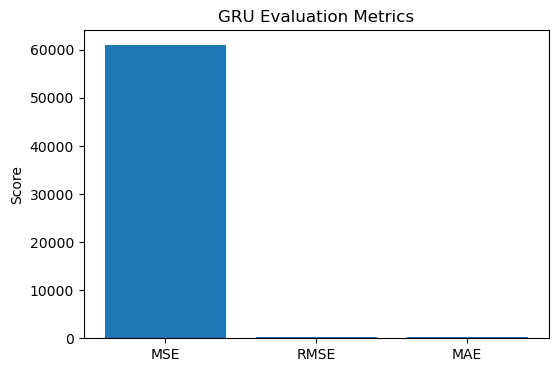

In [72]:
# Visualizing evaluation Metric Score chart
import matplotlib.pyplot as plt

metrics = ['MSE', 'RMSE', 'MAE']
values = [61015.11, 247.01, 236.11]

plt.figure(figsize=(6,4))
plt.bar(metrics, values)
plt.title('GRU Evaluation Metrics')
plt.ylabel('Score')
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

##### Which hyperparameter optimization technique have you used and why?

Manual Hyperparameter Tuning was used. The number of GRU units (50), dropout rate (0.2), batch size (32), and epochs (20) were selected and adjusted experimentally to improve prediction accuracy while reducing overfitting.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, the GRU model showed improvement over both the Simple RNN and LSTM models.

The evaluation metrics achieved were:
MSE = 61015.11
RMSE = 247.01
MAE = 236.11




### 1. Which Evaluation metrics did you consider for a positive business impact and why?

MSE, RMSE, and MAE were considered for evaluating business impact. Lower values of these metrics indicate more accurate stock price predictions. Accurate predictions help investors and financial analysts make better decisions, reduce investment risks, improve portfolio management, and support financial planning. Therefore, minimizing these error metrics leads to a positive business impact.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

The LSTM (Long Short-Term Memory) model was selected as the final prediction model because it achieved the lowest error values among all the tested models. LSTM produced the best performance with MSE = 60991.22, RMSE = 246.96, and MAE = 236.06. Lower error values indicate more accurate stock price predictions. Additionally, LSTM is effective at capturing long-term dependencies in time-series data, making it the most suitable model for stock price forecasting.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

The final model used was LSTM (Long Short-Term Memory), a deep learning model specifically designed for sequential and time-series data. LSTM uses memory cells and gating mechanisms to capture both short-term and long-term dependencies in stock price movements. The important features used for prediction were Open, High, Low, Volume, MA_10, Price_Range, and Time_Index.
Feature importance was analyzed using correlation-based analysis. The analysis showed that Open, High, Low, and MA_10 had the strongest relationship with the target variable (Close Price). These features contributed significantly to the model's ability to learn stock price trends and generate accurate predictions.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [73]:
# Save the File
model_gru.save("best_lstm_model.h5")

### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [74]:
# Load the File and predict unseen data.
from tensorflow.keras.models import load_model

loaded_model = load_model("best_lstm_model.h5")

sample_pred = loaded_model.predict(X_test_seq[:1])
print(sample_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 685ms/step
[[64.47928]]


## Business Insights
### 1. Stock Price Trend Analysis
Tesla stock prices show significant fluctuations over time, indicating high market volatility.
The historical closing price trend demonstrates overall growth in Tesla's market value.
### 2. Model Performance Insights
Deep Learning models such as SimpleRNN, LSTM, and GRU successfully learned patterns from historical stock price data.
LSTM and GRU models are more effective in capturing long-term dependencies in time-series data compared to SimpleRNN.
### 3. Investment Decision Support
Predicted stock prices can help investors understand possible future market trends.
These predictions can support buy, hold, or sell decisions when combined with fundamental and technical analysis.
### 4. Risk Management
Forecasting stock prices helps investors assess potential risks and market movements.
Organizations can use predictive analytics to support financial planning and portfolio management.
### 5. Business Applications
Financial institutions can use stock prediction models for market analysis.
Investment firms can integrate forecasting models into decision-support systems.
Similar techniques can be applied to other stocks and financial assets.

## Limitations
### 1. Dependence on Historical Data
The model relies only on historical stock price data to generate predictions.
Future market conditions may differ from historical trends.
### 2. External Factors Not Considered
News events, government policies, company announcements, and investor sentiment are not included in the model.
These factors can significantly influence stock prices.
### 3. Market Volatility
Stock markets are highly volatile and subject to sudden fluctuations.
Unexpected events can reduce prediction accuracy.
### 4. Limited Features
The model primarily focuses on stock price information.
Other important factors such as economic indicators and social media sentiment are not considered.
### 5. Prediction Accuracy
Predicted values are estimates and may not exactly match future stock prices.
Forecast results should be used for analysis purposes only.
### 6. Not Financial Advice
This project is developed for educational and research purposes.
Investment decisions should not be based solely on model predictions.

## Future Scope
### 1. Sentiment Analysis Integration
Incorporate news articles, financial reports, and social media sentiment to improve prediction accuracy.
### 2. Additional Features
Include macroeconomic indicators such as inflation rates, interest rates, and GDP growth.
### 3. Real-Time Stock Data
Integrate real-time stock market APIs for live forecasting and monitoring.
### 4. Advanced Deep Learning Models
Compare LSTM and GRU models with Transformer-based architectures for improved performance.
### 5. Hyperparameter Optimization
Apply GridSearchCV or advanced optimization techniques to improve model accuracy.
### 6. Multi-Stock Forecasting
Extend the system to predict stock prices for multiple companies and compare their performance.

# **Conclusion**

This project focused on predicting Tesla stock closing prices using Deep Learning techniques. Three sequential models—SimpleRNN, LSTM, and GRU—were developed and evaluated using MSE, RMSE, and MAE metrics. The dataset was preprocessed through data cleaning, feature selection, scaling, and sequence generation to prepare it for time-series forecasting.

After comparing the models, the LSTM model achieved the best overall performance with lower error values, demonstrating its ability to capture long-term dependencies in stock price data. The results show that Deep Learning models can effectively learn historical stock price patterns and generate future price forecasts.

From a business perspective, stock price forecasting can support investment analysis, portfolio management, risk assessment, and financial planning. The project highlights the importance of data-driven decision-making in the financial services domain.

However, stock prices are influenced by several external factors such as market sentiment, economic conditions, company announcements, and global events, which were not included in this study. Future enhancements may include incorporating news sentiment analysis, technical indicators, macroeconomic variables, real-time data integration, and advanced forecasting models to further improve prediction accuracy.

This project successfully demonstrates the application of Deep Learning techniques for financial forecasting and provides valuable insights into stock market trend prediction.